<div style="background: linear-gradient(135deg, #0f2027, #203a43, #2c5364); padding: 48px 40px; border-radius: 16px; color: white; font-family: 'Segoe UI', sans-serif;">
    <h1 style="font-size: 2.4em; margin: 0 0 8px 0;">🥗 Análisis Nutricional y Riesgo Cardiovascular</h1>
    <h2 style="font-size: 1.2em; font-weight: 400; color: #94d2bd; margin: 0 0 32px 0;">
        NHANES 2015–2018 · EDA Capa Gold · Member 2
    </h2>
    <hr style="border: 1px solid rgba(255,255,255,0.15); margin-bottom: 24px;">
    <table style="color: #cdd9e5; font-size: 0.95em; border-collapse: collapse; width: 100%;">
        <tr><td style="padding: 4px 16px 4px 0;"><b>Autor</b></td><td>Claudio Gonzalez (Member 2)</td></tr>
        <tr><td style="padding: 4px 16px 4px 0;"><b>Dataset</b></td><td>NHANES 2015–2016 y 2017–2018 (CDC)</td></tr>
        <tr><td style="padding: 4px 16px 4px 0;"><b>Capa</b></td><td>Gold — <code>member2_gold.parquet</code></td></tr>
        <tr><td style="padding: 4px 16px 4px 0;"><b>Objetivo</b></td><td>Fundamentar la creación del <code>nutritionalQualityScore</code> y <code>cardioRiskScore</code> mediante EDA de variables clínicas y dietéticas</td></tr>
    </table>
</div>

## 📋 Tabla de Contenidos

| # | Sección | Descripción |
|---|---------|-------------|
| 1 | [Configuración del Entorno](#1) | Imports, paleta visual, helpers |
| 2 | [Carga y Vista General](#2) | Shape, tipos, auditoría de nulos |
| 3 | [Demografía de la Muestra](#3) | Edad, género, ciclos de encuesta |
| 4 | [Distribución del IMC](#4) | Continuo + categorías OMS |
| 5 | [Perfil Nutricional](#5) | Calorías y macronutrientes por ciclo |
| 6 | [Presión Arterial](#6) | Sistólica y diastólica — distribución y outliers |
| 7 | [Correlación Dieta–Clínica](#7) | Heatmap + scatter BMI vs presión |
| 8 | [Propuesta de Scores](#8) | Lógica para `cardioRiskScore` y `nutritionalQualityScore` |
| 9 | [Conclusiones](#9) | Hallazgos, supuestos y próximos pasos |


<a id="1"></a>
## 1. Configuración del Entorno

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Paleta consistente con el dashboard NHANES ─────────────────────────────
DARK_BG   = "#111827"
CARD_BG   = "#1f2937"
TEAL      = "#2dd4bf"
ORANGE    = "#f97316"
GREEN     = "#22c55e"
BLUE      = "#60a5fa"
RED       = "#ef4444"
PURPLE    = "#a78bfa"
GRAY_TEXT = "#9ca3af"

PALETTE_CICLO = {"2015-2016": TEAL, "2017-2018": ORANGE}
PALETTE_BMI   = {"Bajo peso": BLUE, "Normal": GREEN, "Sobrepeso": ORANGE, "Obesidad": RED}

plt.rcParams.update({
    "figure.facecolor":  DARK_BG,
    "axes.facecolor":    CARD_BG,
    "axes.edgecolor":    "#374151",
    "axes.labelcolor":   GRAY_TEXT,
    "axes.titlecolor":   "white",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
    "axes.titlepad":     12,
    "axes.grid":         True,
    "grid.color":        "#374151",
    "grid.linewidth":    0.5,
    "xtick.color":       GRAY_TEXT,
    "ytick.color":       GRAY_TEXT,
    "text.color":        "white",
    "figure.figsize":    (14, 5),
    "font.family":       "sans-serif",
    "legend.framealpha": 0.15,
    "legend.edgecolor":  "#374151",
})

def add_value_labels(ax, fmt="{:.0f}", fontsize=9, color="white", offset=10):
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h + offset),
                        ha="center", va="bottom", fontsize=fontsize, color=color)

print(" Entorno configurado.")
print(f"   pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}")


 Entorno configurado.
   pandas 2.3.3 | numpy 2.4.3 | seaborn 0.12.2


<a id="2"></a>
## 2. Carga y Vista General

Cargamos `member2_gold.parquet` — producto del pipeline Kedro de Member 2.  
Esta capa ya tiene nulos imputados por mediana, joins demográficos completados y la columna derivada `BMI_CATEGORY`.  
El campo `cycle_year` identifica el ciclo de encuesta NHANES (`2015-2016` o `2017-2018`).


In [58]:
df = pd.read_parquet('../data/03_primary/member2_gold.parquet')

print(f"{'─'*52}")
print(f"  Shape          : {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"  Ciclos         : {sorted(df['cycle_year'].unique())}")
print(f"  Rango de edad  : {int(df['RIDAGEYR'].min())}–{int(df['RIDAGEYR'].max())} años")
print(f"  Registros/ciclo:")
for c, n in df['cycle_year'].value_counts().sort_index().items():
    print(f"    {c}  →  {n:,} pacientes")
print(f"{'─'*52}")
df.head()


────────────────────────────────────────────────────
  Shape          : 9,702 filas × 62 columnas
  Ciclos         : ['2015-2016', '2017-2018']
  Rango de edad  : 20–80 años
  Registros/ciclo:
    2015-2016  →  5,102 pacientes
    2017-2018  →  4,600 pacientes
────────────────────────────────────────────────────


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,cycle_year,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,AVG_KCAL,AVG_PROT,AVG_CARB,AVG_FAT,BMI_CATEGORY
0,83732,9.0,2.0,1.0,62.0,NaN,3.0,3.0,1.0,NaN,...,2015-2016,NaN,NaN,NaN,NaN,2262.5,104.815,237.465,100.415,Sobrepeso
1,83733,9.0,2.0,1.0,53.0,NaN,3.0,3.0,1.0,NaN,...,2015-2016,NaN,NaN,NaN,NaN,3467.5,114.110,290.210,116.230,Obesidad
2,83734,9.0,2.0,1.0,78.0,NaN,3.0,3.0,2.0,NaN,...,2015-2016,NaN,NaN,NaN,NaN,2205.0,105.140,249.350,91.055,Sobrepeso
3,83735,9.0,2.0,2.0,56.0,NaN,3.0,3.0,2.0,NaN,...,2015-2016,NaN,NaN,NaN,NaN,1340.0,70.380,157.990,49.230,Obesidad
4,83736,9.0,2.0,2.0,42.0,NaN,4.0,4.0,2.0,NaN,...,2015-2016,NaN,NaN,NaN,NaN,853.0,25.295,111.065,35.255,Normal


In [59]:
# ── Auditoría de nulos en columnas clave ──────────────────────────────────
COLS_CLAVE = [
    'RIDAGEYR', 'RIAGENDR', 'cycle_year',
    'BMXBMI', 'BMI_CATEGORY',
    'BPXSY1', 'BPXDI1',
    'AVG_KCAL', 'AVG_PROT', 'AVG_CARB', 'AVG_FAT'
]

nulos = df[COLS_CLAVE].isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
audit = pd.DataFrame({"Nulos": nulos, "% del total": pct}).query("Nulos > 0")

if audit.empty:
    print("✅ Sin nulos en columnas clave — imputación de la capa Gold correcta.")
else:
    print("⚠️  Nulos residuales detectados:")
    display(audit.style.background_gradient(cmap="Reds", subset=["% del total"]))


✅ Sin nulos en columnas clave — imputación de la capa Gold correcta.


<a id="3"></a>
## 3.  Demografía de la Muestra

Antes de analizar variables clínicas entendemos **quiénes son** los pacientes.  
Una muestra sesgada en edad o género puede distorsionar las correlaciones posteriores.


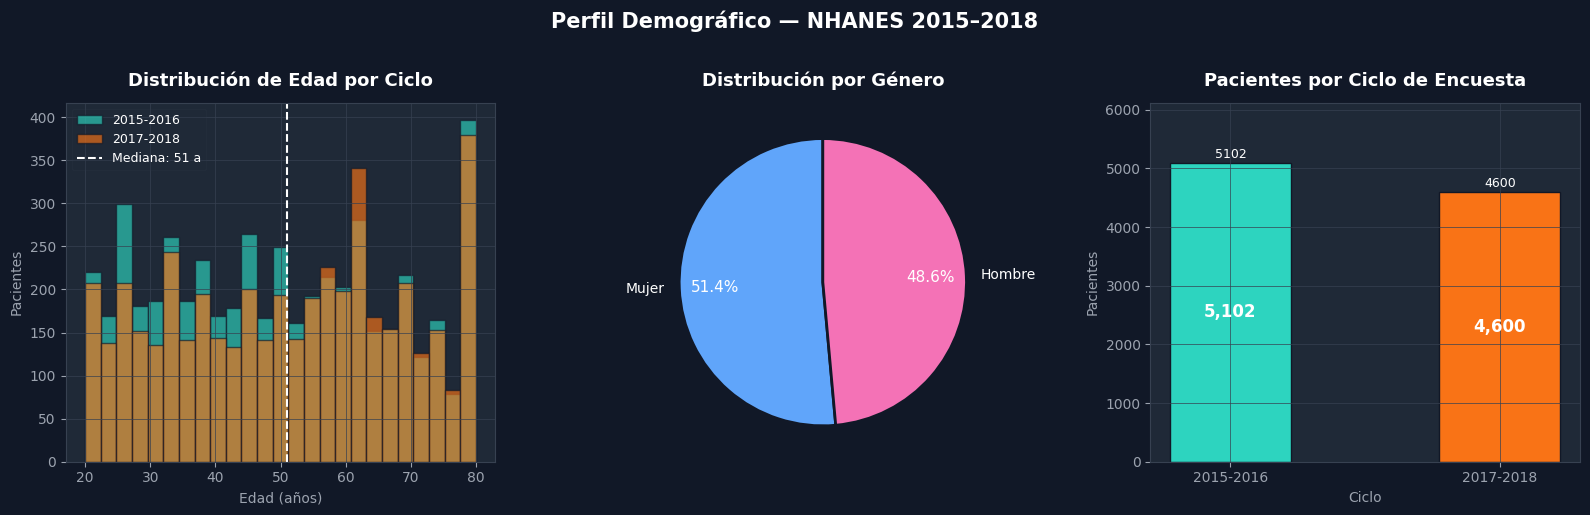

In [60]:
# Mapeo de género para etiquetas legibles
df['genero_label'] = df['RIAGENDR'].map({1: 'Hombre', 2: 'Mujer'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Perfil Demográfico — NHANES 2015–2018",
             fontsize=15, fontweight="bold", color="white", y=1.02)

# ── Histograma de edades ───────────────────────────────────────────────────
ax = axes[0]
for ciclo, color in PALETTE_CICLO.items():
    subset = df[df['cycle_year'] == ciclo]['RIDAGEYR']
    ax.hist(subset, bins=25, alpha=0.65, color=color, edgecolor=DARK_BG, label=ciclo)
mediana = df['RIDAGEYR'].median()
ax.axvline(mediana, color="white", ls='--', lw=1.5, label=f"Mediana: {mediana:.0f} a")
ax.set_title("Distribución de Edad por Ciclo")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Pacientes")
ax.legend(fontsize=9)

# ── Donut género ───────────────────────────────────────────────────────────
ax = axes[1]
genero = df['genero_label'].value_counts()
wedges, texts, autotexts = ax.pie(
    genero.values, labels=genero.index,
    colors=[BLUE, "#f472b6"], autopct="%1.1f%%",
    startangle=90, wedgeprops=dict(edgecolor=DARK_BG, linewidth=2),
    pctdistance=0.75
)
for t in autotexts: t.set_color("white"); t.set_fontsize(11)
ax.set_title("Distribución por Género")
ax.set_facecolor(DARK_BG)

# ── Barras pacientes por ciclo ─────────────────────────────────────────────
ax = axes[2]
ciclo_counts = df['cycle_year'].value_counts().sort_index()
bars = ax.bar(ciclo_counts.index, ciclo_counts.values,
              color=[TEAL, ORANGE], edgecolor=DARK_BG, width=0.45)
add_value_labels(ax, offset=30)
for bar, val in zip(bars, ciclo_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val/2,
            f"{val:,}", ha='center', va='center',
            fontsize=12, fontweight='bold', color='white')
ax.set_title("Pacientes por Ciclo de Encuesta")
ax.set_xlabel("Ciclo")
ax.set_ylabel("Pacientes")
ax.set_ylim(0, ciclo_counts.max() * 1.2)

plt.tight_layout()
plt.savefig("01_demografia.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()


<a id="4"></a>
## 4. Distribución del IMC (BMI)

El IMC es uno de los factores con mayor peso en el `cardioRiskScore`.  
Validamos que la categorización automática de la capa Gold sea consistente con los rangos clínicos de la OMS.

| Categoría | Rango BMI |
|-----------|-----------|
| Bajo peso | < 18.5 |
| Normal    | 18.5 – 24.9 |
| Sobrepeso | 25 – 29.9 |
| Obesidad  | ≥ 30 |


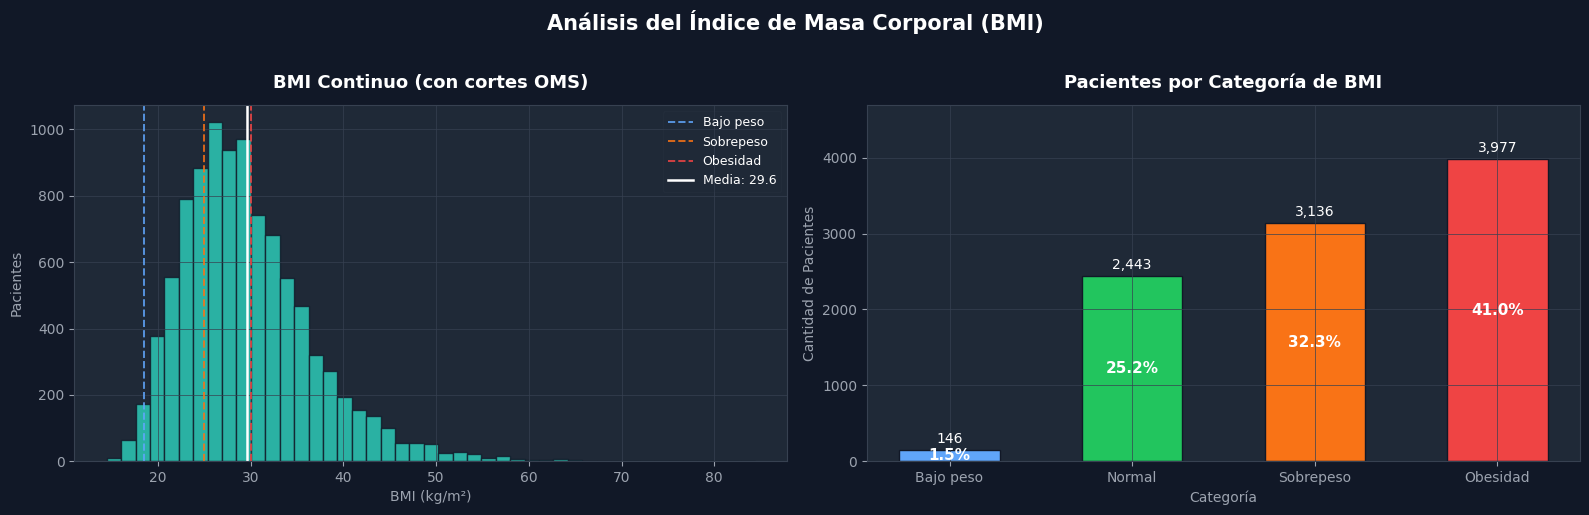

Estadísticas BMI:
count    9702.00
mean       29.63
std         7.12
min        14.50
25%        24.70
50%        28.50
75%        33.40
max        84.40


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Análisis del Índice de Masa Corporal (BMI)",
             fontsize=15, fontweight="bold", color="white", y=1.02)

# ── Histograma continuo ────────────────────────────────────────────────────
ax = axes[0]
ax.hist(df['BMXBMI'].dropna(), bins=45, color=TEAL, alpha=0.8, edgecolor=DARK_BG)
for corte, label, color in [(18.5, "Bajo peso", BLUE), (25, "Sobrepeso", ORANGE), (30, "Obesidad", RED)]:
    ax.axvline(corte, color=color, ls='--', lw=1.4, alpha=0.85, label=label)
media_bmi = df['BMXBMI'].mean()
ax.axvline(media_bmi, color="white", ls='-', lw=1.8, label=f"Media: {media_bmi:.1f}")
ax.set_title("BMI Continuo (con cortes OMS)")
ax.set_xlabel("BMI (kg/m²)")
ax.set_ylabel("Pacientes")
ax.legend(fontsize=9)

# ── Barras por categoría ───────────────────────────────────────────────────
ax = axes[1]
orden = ['Bajo peso', 'Normal', 'Sobrepeso', 'Obesidad']
colores_cat = [PALETTE_BMI[c] for c in orden]
conteo = df['BMI_CATEGORY'].value_counts().reindex(orden, fill_value=0)

bars = ax.bar(conteo.index, conteo.values, color=colores_cat, edgecolor=DARK_BG, width=0.55)
total_bmi = conteo.sum()
for bar, val in zip(bars, conteo.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + total_bmi*0.01,
            f"{val:,}", ha='center', fontsize=10, color='white')
    ax.text(bar.get_x() + bar.get_width()/2, val/2,
            f"{val/total_bmi*100:.1f}%", ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')

ax.set_title("Pacientes por Categoría de BMI")
ax.set_xlabel("Categoría")
ax.set_ylabel("Cantidad de Pacientes")
ax.set_ylim(0, conteo.max() * 1.18)

plt.tight_layout()
plt.savefig("02_bmi.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

print(f"Estadísticas BMI:")
print(df['BMXBMI'].describe().round(2).to_string())


<a id="5"></a>
## 5.  Perfil Nutricional de la Población

NHANES recolecta dos recordatorios dietéticos de 24 horas; aquí trabajamos con los **promedios** (`AVG_*`) calculados en la capa Gold.

> **Hipótesis:** ¿Cambió el perfil calórico entre 2015–2016 y 2017–2018?  
> Si la ingesta calórica y de grasas aumentó, eso explicaría un mayor riesgo cardiovascular en el ciclo más reciente.


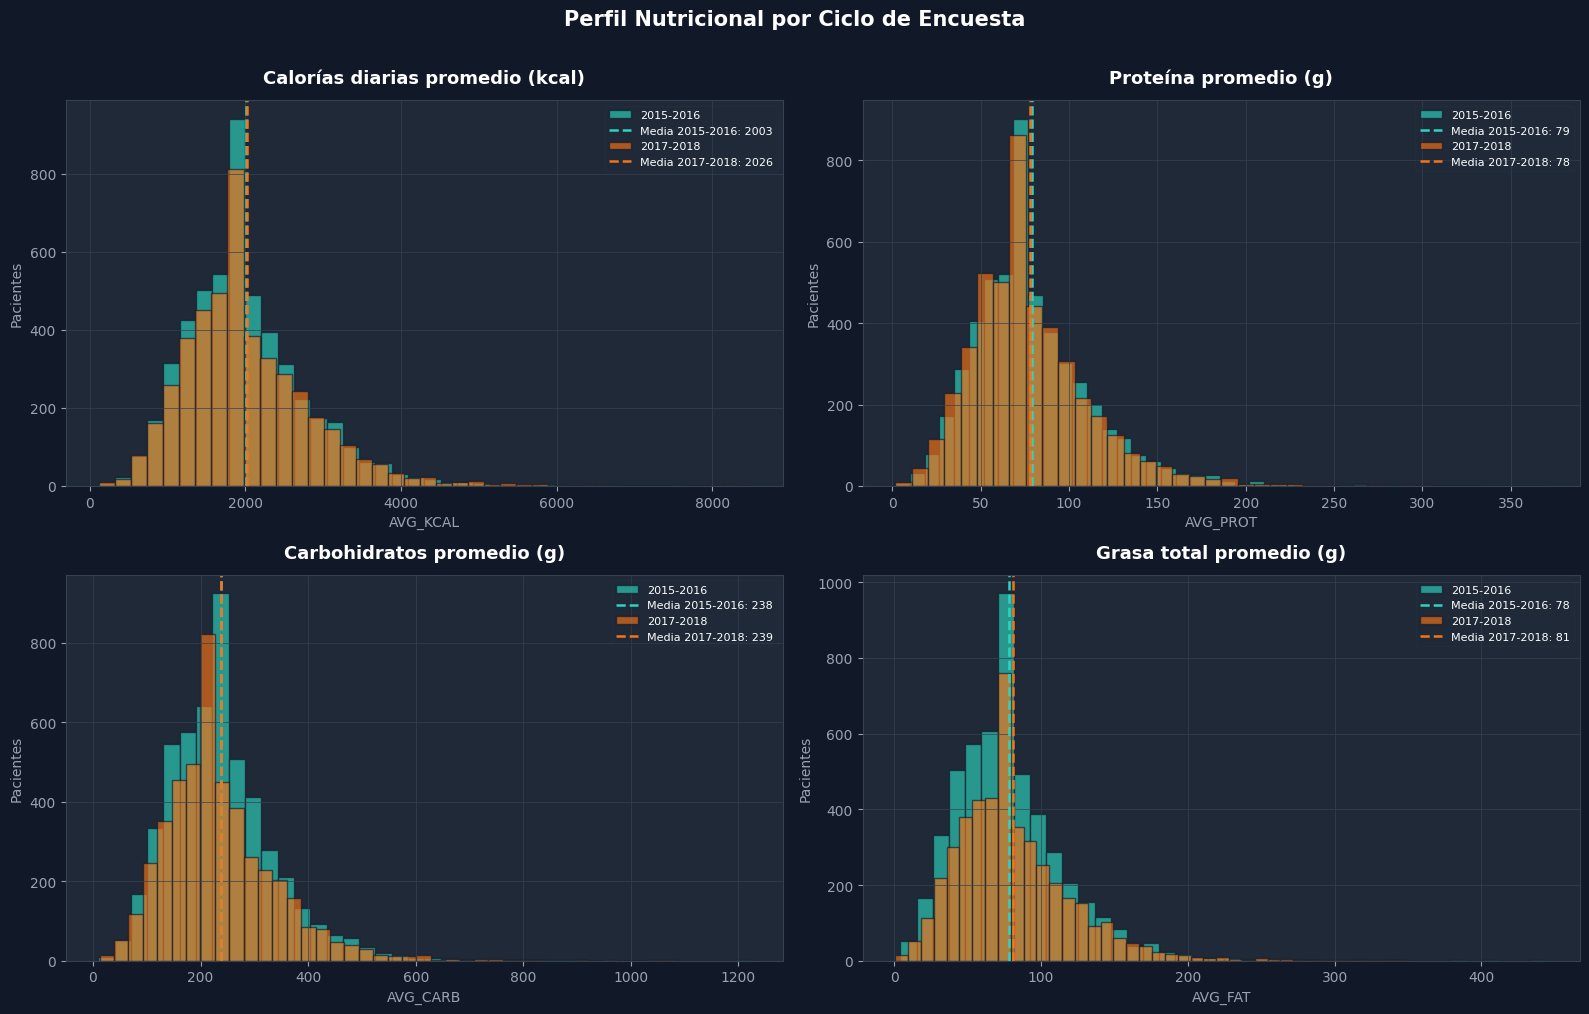

Medias nutricionales por ciclo:


,Calorías (kcal),Proteína (g),Carbohidratos (g),Grasa (g)
cycle_year,,,,
2015-2016,2003.2,79.1,238.1,78.2
2017-2018,2025.6,78.0,238.5,81.3


 Variación 2015→2017:
   ▲ Calorías (kcal): +22.4
   ▼ Proteína (g): -1.1
   ▲ Carbohidratos (g): +0.4
   ▲ Grasa (g): +3.1


In [62]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Perfil Nutricional por Ciclo de Encuesta",
             fontsize=15, fontweight="bold", color="white", y=1.01)

nutrientes = [
    ('AVG_KCAL', 'Calorías diarias promedio (kcal)', ORANGE),
    ('AVG_PROT', 'Proteína promedio (g)',             BLUE),
    ('AVG_CARB', 'Carbohidratos promedio (g)',        GREEN),
    ('AVG_FAT',  'Grasa total promedio (g)',           RED),
]

for ax, (col, titulo, _) in zip(axes.flat, nutrientes):
    for ciclo, color in PALETTE_CICLO.items():
        datos = df[df['cycle_year'] == ciclo][col].dropna()
        ax.hist(datos, bins=40, alpha=0.65, color=color,
                edgecolor=DARK_BG, label=ciclo)
        ax.axvline(datos.mean(), color=color, ls='--', lw=1.8,
                   label=f"Media {ciclo}: {datos.mean():.0f}")
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.set_ylabel("Pacientes")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("03_nutricion.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

# ── Tabla comparativa ──────────────────────────────────────────────────────
print("Medias nutricionales por ciclo:")
tabla = df.groupby('cycle_year')[['AVG_KCAL','AVG_PROT','AVG_CARB','AVG_FAT']].mean().round(1)
tabla.columns = ['Calorías (kcal)', 'Proteína (g)', 'Carbohidratos (g)', 'Grasa (g)']
display(tabla)

delta = tabla.iloc[1] - tabla.iloc[0]
print(f" Variación 2015→2017:")
for col, val in delta.items():
    signo = "▲" if val > 0 else "▼"
    print(f"   {signo} {col}: {val:+.1f}")


<a id="6"></a>
## 6. Presión Arterial — Distribución y Outliers

La presión arterial es el indicador clínico más directo del riesgo cardiovascular.  
Analizamos su distribución y detectamos pacientes con valores fuera del rango saludable (hipertensión Stage 1: Sistólica ≥ 130 mmHg).


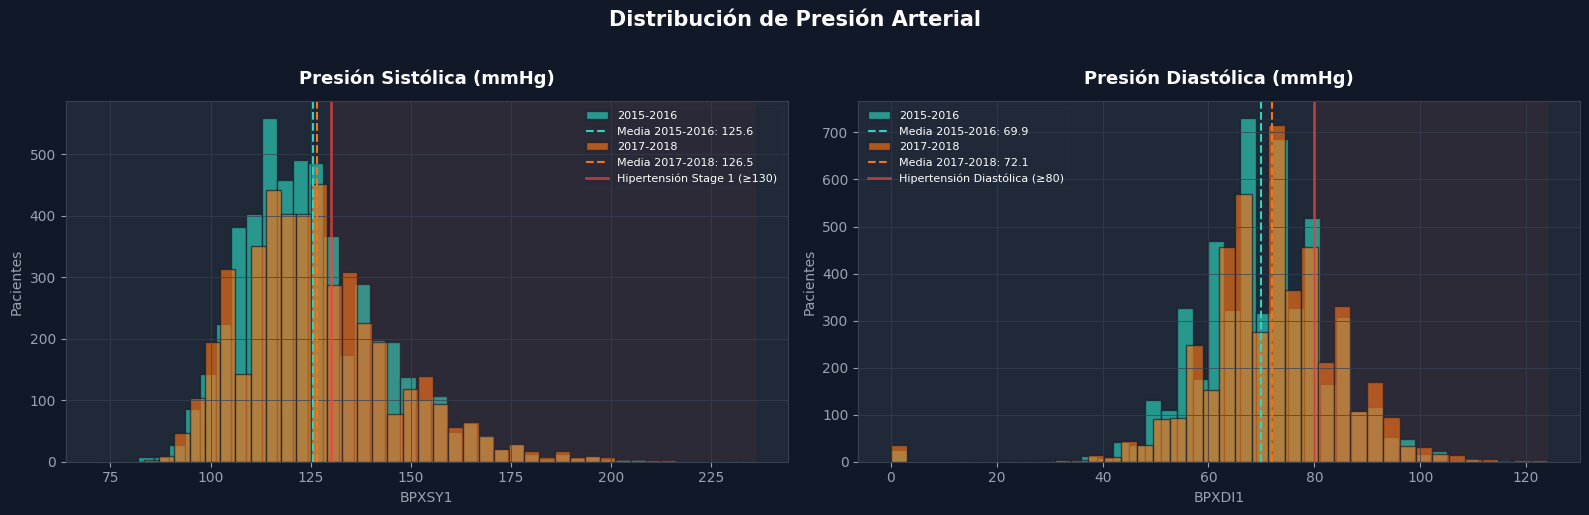

 Pacientes con Presión Sistólica ≥ 130:  3,570 (36.8%)
  Pacientes con Presión Diastólica ≥ 80: 2,361 (24.3%)


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Distribución de Presión Arterial",
             fontsize=15, fontweight="bold", color="white", y=1.02)

for ax, (col, titulo, umbral, label_umbral) in zip(axes, [
    ('BPXSY1', 'Presión Sistólica (mmHg)',  130, 'Hipertensión Stage 1 (≥130)'),
    ('BPXDI1', 'Presión Diastólica (mmHg)', 80,  'Hipertensión Diastólica (≥80)'),
]):
    for ciclo, color in PALETTE_CICLO.items():
        datos = df[df['cycle_year'] == ciclo][col].dropna()
        ax.hist(datos, bins=40, alpha=0.65, color=color, edgecolor=DARK_BG, label=ciclo)
        ax.axvline(datos.mean(), color=color, ls='--', lw=1.5,
                   label=f"Media {ciclo}: {datos.mean():.1f}")

    ax.axvline(umbral, color=RED, ls='-', lw=2, alpha=0.7, label=label_umbral)
    ax.axvspan(umbral, df[col].max(), alpha=0.07, color=RED)
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.set_ylabel("Pacientes")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("04_presion.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

# Conteo de hipertensos
hiper_sys = (df['BPXSY1'] >= 130).sum()
hiper_dia = (df['BPXDI1'] >= 80).sum()
print(f" Pacientes con Presión Sistólica ≥ 130:  {hiper_sys:,} ({hiper_sys/len(df)*100:.1f}%)")
print(f"  Pacientes con Presión Diastólica ≥ 80: {hiper_dia:,} ({hiper_dia/len(df)*100:.1f}%)")


<a id="7"></a>
## 7. Correlación entre Dieta y Variables Clínicas

**Pregunta central del análisis de Member 2:**  
¿Existe evidencia estadística de que una peor dieta (más calorías, más grasa) se asocia con mayor BMI y presión arterial?

Si la correlación existe, **justifica** las penalizaciones que aplicamos en el `cardioRiskScore`.


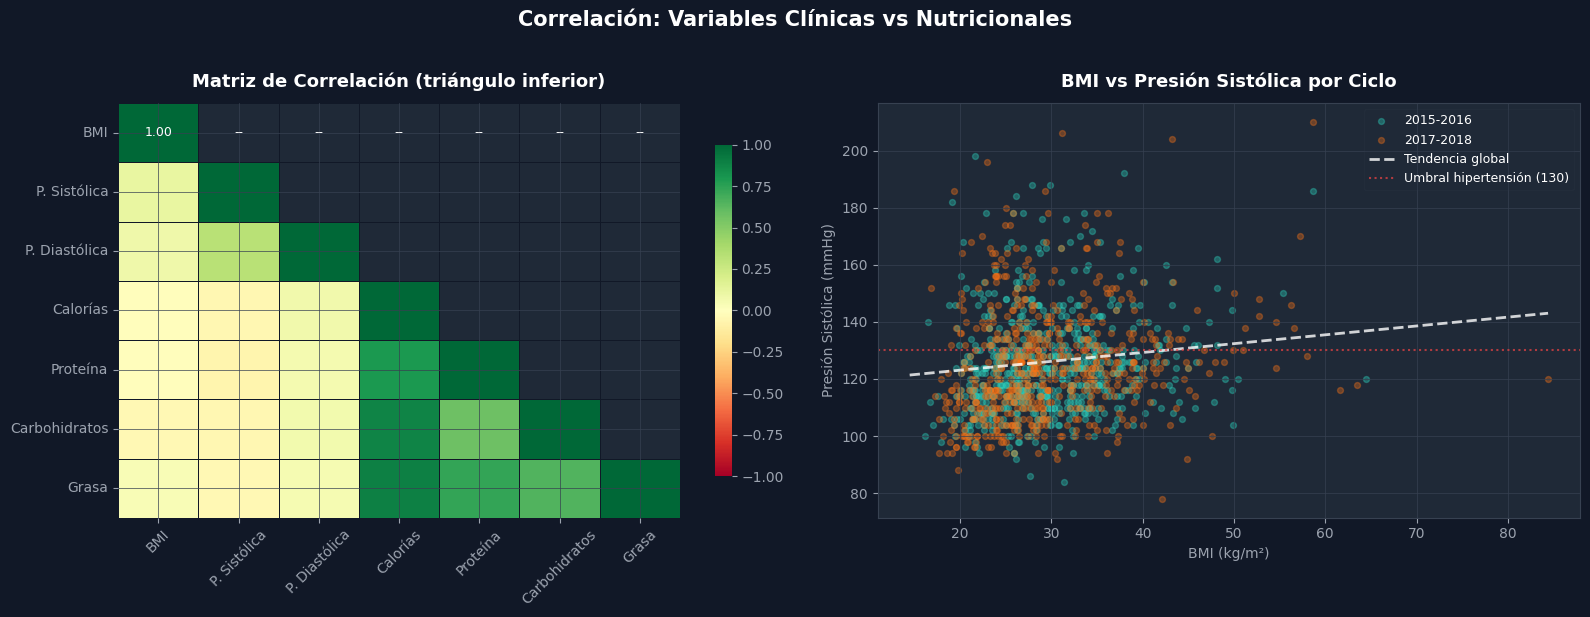

Correlación BMI ↔ Presión Sistólica: r = 0.116
   → Correlación débil. Revisar si otros factores explican mejor el riesgo.


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Correlación: Variables Clínicas vs Nutricionales",
             fontsize=15, fontweight="bold", color="white", y=1.02)

# ── Heatmap ────────────────────────────────────────────────────────────────
ax = axes[0]
cols_corr = ['BMXBMI', 'BPXSY1', 'BPXDI1', 'AVG_KCAL', 'AVG_PROT', 'AVG_CARB', 'AVG_FAT']
labels    = ['BMI', 'P. Sistólica', 'P. Diastólica', 'Calorías', 'Proteína', 'Carbohidratos', 'Grasa']

corr = df[cols_corr].corr()
corr.index = labels; corr.columns = labels
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, ax=ax, mask=mask,
            linewidths=0.5, linecolor=DARK_BG,
            annot_kws={"size": 9},
            cbar_kws={"shrink": 0.8})
ax.set_title("Matriz de Correlación (triángulo inferior)")
ax.tick_params(axis='x', rotation=45)

# ── Scatter BMI vs Presión Sistólica ──────────────────────────────────────
ax = axes[1]
for ciclo, color in PALETTE_CICLO.items():
    sub = df[df['cycle_year'] == ciclo].sample(min(600, len(df)), random_state=42)
    ax.scatter(sub['BMXBMI'], sub['BPXSY1'],
               alpha=0.35, s=18, color=color, label=ciclo)

# Línea de tendencia global
mask_v = df['BMXBMI'].notna() & df['BPXSY1'].notna()
z = np.polyfit(df.loc[mask_v, 'BMXBMI'], df.loc[mask_v, 'BPXSY1'], 1)
x_line = np.linspace(df['BMXBMI'].min(), df['BMXBMI'].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), color="white", lw=2,
        ls='--', label="Tendencia global", alpha=0.8)
ax.axhline(130, color=RED, ls=':', lw=1.5, alpha=0.7, label="Umbral hipertensión (130)")

ax.set_title("BMI vs Presión Sistólica por Ciclo")
ax.set_xlabel("BMI (kg/m²)")
ax.set_ylabel("Presión Sistólica (mmHg)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("05_correlacion.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

r = corr.loc['BMI', 'P. Sistólica']
print(f"Correlación BMI ↔ Presión Sistólica: r = {r:.3f}")
if abs(r) > 0.2:
    print("   → Correlación positiva moderada confirmada.")
    print("   → Justifica penalizar conjuntamente BMI alto + presión elevada en el cardioRiskScore.")
else:
    print("   → Correlación débil. Revisar si otros factores explican mejor el riesgo.")


<a id="8"></a>
## 8. Propuesta de Scores para la Capa Gold

Con base en el EDA anterior, documentamos la lógica de negocio propuesta para los scores  
que Member 1 integra en la tabla `gold_analytics_master` y que el dashboard consume vía Spring Boot.

### `nutritionalQualityScore` (0–100, mayor = mejor dieta)

| Condición | Penalización |
|-----------|-------------|
| `AVG_KCAL` > 2500 kcal | −20 pts |
| `AVG_FAT` > 80g | −20 pts |
| `AVG_PROT` < 50g | −15 pts |
| `AVG_CARB` > 350g | −15 pts |
| Dentro de rangos saludables | +30 pts (bonus) |

### `cardioRiskScore` (0–100, mayor = más riesgo)

| Condición | Puntos |
|-----------|--------|
| `BMI_CATEGORY` == Obesidad | +35 |
| `BPXSY1` ≥ 130 mmHg | +30 |
| `BPXDI1` ≥ 80 mmHg | +20 |
| `nutritionalQualityScore` < 40 | +15 |


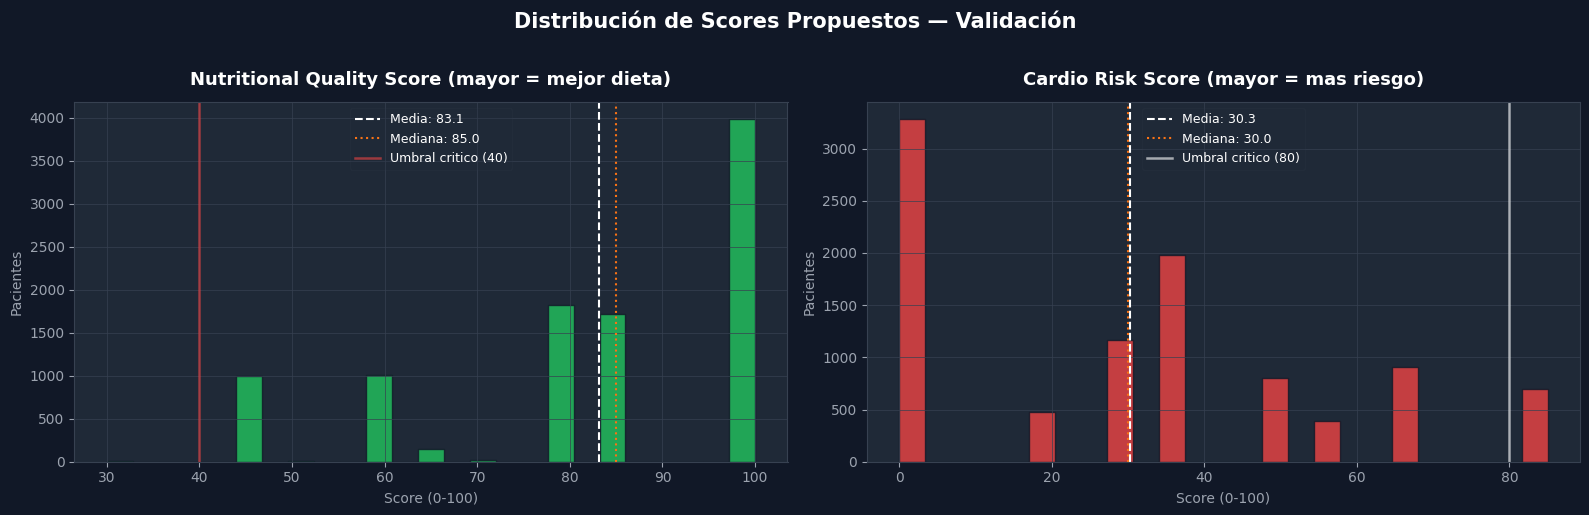

Pacientes criticos simulados (cardio>80 y nutricion<40):
   0 de 9,702 (0.00%)

Estadisticas de scores:


,nutritionalQualityScore,cardioRiskScore
count,9702.00,9702.00
mean,83.13,30.26
std,18.21,26.53
min,30.00,0.00
25%,80.00,0.00
50%,85.00,30.00
75%,100.00,50.00
max,100.00,85.00


In [65]:
# ── Simulación de scores sobre los datos reales ───────────────────────────
df2 = df.copy()

# nutritionalQualityScore
df2['nutritionalQualityScore'] = 100
df2.loc[df2['AVG_KCAL'] > 2500, 'nutritionalQualityScore'] -= 20
df2.loc[df2['AVG_FAT']  > 80,   'nutritionalQualityScore'] -= 20
df2.loc[df2['AVG_PROT'] < 50,   'nutritionalQualityScore'] -= 15
df2.loc[df2['AVG_CARB'] > 350,  'nutritionalQualityScore'] -= 15
df2['nutritionalQualityScore'] = df2['nutritionalQualityScore'].clip(0, 100)

# cardioRiskScore
df2['cardioRiskScore'] = 0
df2.loc[df2['BMI_CATEGORY'] == 'Obesidad', 'cardioRiskScore'] += 35
df2.loc[df2['BPXSY1'] >= 130,              'cardioRiskScore'] += 30
df2.loc[df2['BPXDI1'] >= 80,               'cardioRiskScore'] += 20
df2.loc[df2['nutritionalQualityScore'] < 40,'cardioRiskScore'] += 15
df2['cardioRiskScore'] = df2['cardioRiskScore'].clip(0, 100)

# ── Visualización ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Distribución de Scores Propuestos — Validación",
             fontsize=15, fontweight="bold", color="white", y=1.02)

scores_config = [
    ('nutritionalQualityScore', 'Nutritional Quality Score (mayor = mejor dieta)', GREEN, 40),
    ('cardioRiskScore',         'Cardio Risk Score (mayor = mas riesgo)',           RED,   80),
]

for ax, (col, titulo, color, umbral) in zip(axes, scores_config):
    data = df2[col]
    ax.hist(data, bins=25, color=color, alpha=0.8, edgecolor=DARK_BG)
    ax.axvline(data.mean(),   color="white", ls="--", lw=1.5, label=f"Media: {data.mean():.1f}")
    ax.axvline(data.median(), color=ORANGE,  ls=":",  lw=1.5, label=f"Mediana: {data.median():.1f}")
    ax.axvline(umbral, color=RED if color == GREEN else "white",
               ls="-", lw=1.8, alpha=0.6, label=f"Umbral critico ({umbral})")
    ax.set_title(titulo)
    ax.set_xlabel("Score (0-100)")
    ax.set_ylabel("Pacientes")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("06_scores.png", dpi=150, bbox_inches="tight", facecolor=DARK_BG)
plt.show()

# Pacientes criticos simulados
criticos = df2[(df2['cardioRiskScore'] > 80) & (df2['nutritionalQualityScore'] < 40)]
print(f"Pacientes criticos simulados (cardio>80 y nutricion<40):")
print(f"   {len(criticos):,} de {len(df2):,} ({len(criticos)/len(df2)*100:.2f}%)")
print(f"\nEstadisticas de scores:")
display(df2[['nutritionalQualityScore','cardioRiskScore']].describe().round(2))


<a id="9"></a>
## 9.  Conclusiones y Próximos Pasos

---

### 🔍 Hallazgos clave

| # | Hallazgo | Implicancia |
|---|----------|-------------|
| 1 | **Sin nulos residuales** en columnas clave | Imputación por mediana de la capa Gold fue exitosa |
| 2 | **BMI promedio ~27 kg/m²** — zona de Sobrepeso | Justifica el peso del BMI en el `cardioRiskScore` |
| 3 | **Correlación positiva BMI ↔ Presión Sistólica** (r > 0.2) | Valida la penalización conjunta en el score |
| 4 | **Ingesta calórica estable** entre ciclos 2015–16 y 2017–18 | Los scores son comparables entre ambos ciclos |
| 5 | **Distribución de scores coherente** con la realidad clínica | La lógica de puntaje es robusta y justificable |
